# Forecasting Model

This notebook develops forecasting models to predict parking demand using hourly transaction counts. The target variable is the number of parking transactions recorded per site per hour.

Three forecasting models are evaluated:

- Linear Regression as the baseline model
- XGBoost as the machine learning model
- LSTM as the deep learning time-series model

Model performance is evaluated using MAE and RMSE because forecasting is a supervised regression task where predicted demand can be compared against actual observed demand.

## Import Libraries and Configure Paths

In [ ]:
from pathlib import Path
import warnings
import holidays
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from xgboost import XGBRegressor

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [120]:
# --- Project paths ---
PROJECT_ROOT = Path(
    r"C:\Users\irfan\OneDrive\Documents\Education\Degree\Third Year\Sem 2\Investigation (fyp)\fyp part 1\parking_fyp"
)

INPUT_FILE    = PROJECT_ROOT / "data" / "processed" / "parking_transactions_cleaned.csv"
OUTPUT_DIR    = PROJECT_ROOT / "outputs"
FIGURE_DIR    = OUTPUT_DIR / "forecasting" / "figures"
DASHBOARD_DIR = OUTPUT_DIR / "dashboard"
MODEL_DIR     = PROJECT_ROOT / "models"

for d in (FIGURE_DIR, DASHBOARD_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Input exists:", INPUT_FILE.exists())

Project root: C:\Users\irfan\OneDrive\Documents\Education\Degree\Third Year\Sem 2\Investigation (fyp)\fyp part 1\parking_fyp
Input exists: True


## Load the cleaned dataset

In [121]:
df = pd.read_csv(
     r"C:\Users\irfan\OneDrive\Documents\Education\Degree\Third Year\Sem 2\Investigation (fyp)\fyp part 1\parking_fyp\data\processed\parking_transactions_cleaned.csv",
    parse_dates=["transaction_dateIn", "transaction_dateOut"],
)

# Normalized entry date (midnight timestamp) for daily grouping
df["entry_date"] = df["transaction_dateIn"].dt.normalize()

print("Loaded shape:", df.shape)
df[["site", "transaction_dateIn", "amount", "parking_duration_minutes"]].head()

Loaded shape: (87440, 22)


,site,transaction_dateIn,amount,parking_duration_minutes
0,Site A,2025-01-01 07:48:30,0.000,6.933
1,Site A,2025-01-01 14:41:08,0.000,1.667
2,Site A,2025-01-01 14:38:23,0.000,32.417
3,Site A,2025-01-01 10:16:10,10.000,304.433
4,Site A,2025-01-01 16:36:45,0.000,26.267


## Build the daily demand series

Demand is measured as the number of transactions per site per day. This daily series is the
target the forecasting models will predict.

In [122]:
daily_demand = (
    df.groupby(["site", "entry_date"])
      .size()
      .reset_index(name="daily_transactions")
      .sort_values(["site", "entry_date"])
)

print("Daily demand shape:", daily_demand.shape)
daily_demand.head()

Daily demand shape: (1013, 3)


,site,entry_date,daily_transactions
0,Site A,2025-01-01,11
1,Site A,2025-01-02,32
2,Site A,2025-01-03,41
3,Site A,2025-01-04,13
4,Site A,2025-01-05,18


## Identify missing dates per site

A full calendar year has 365 days, but not every site recorded activity on every day. Each site's
observed dates are compared against the full 2025 calendar to quantify the gaps.

In [123]:
full_2025 = pd.date_range("2025-01-01", "2025-12-31", freq="D")

coverage_rows = []
missing_dates_by_site = {}

for site in sorted(daily_demand["site"].unique()):
    observed = set(daily_demand.loc[daily_demand["site"] == site, "entry_date"])
    missing = sorted(d for d in full_2025 if d not in observed)
    missing_dates_by_site[site] = missing
    coverage_rows.append({
        "site": site,
        "recorded_days": len(observed),
        "missing_days": len(missing),
        "first_recorded": min(observed).date(),
        "last_recorded": max(observed).date(),
    })

coverage = pd.DataFrame(coverage_rows)
print(coverage.to_string(index=False))

  site  recorded_days  missing_days first_recorded last_recorded
Site A            364             1     2025-01-01    2025-12-31
Site B            300            65     2025-01-02    2025-12-31
Site C            349            16     2025-01-01    2025-12-29


## Investigate the pattern of Site's missing dates

Site B has by far the most gaps. Before deciding how to treat them, the pattern is examined to
distinguish a genuine **closure** (which should be filled as zero-demand) from **sporadic data
loss / downtime** (which should not be zero-filled). Three checks are used:

1. **Weekday distribution** — if the gaps fall on specific weekdays (e.g. all Sundays), it points to a regular operating schedule.
2. **Monthly distribution** — clustering in certain months points to a seasonal closure.
3. **Consecutive blocks** — one long run of consecutive days points to a closure period; many isolated single days point to sporadic gaps.


In [124]:
sb_missing = pd.DatetimeIndex(missing_dates_by_site["Site B"])

print("Site B - total missing dates:", len(sb_missing))

print("\nBy weekday:")
print(sb_missing.day_name().value_counts())

print("\nBy month:")
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
print(sb_missing.month_name().value_counts().reindex(month_order).dropna().astype(int))

Site B - total missing dates: 65

By weekday:
Sunday       44
Monday        6
Saturday      4
Tuesday       4
Thursday      3
Wednesday     2
Friday        2
Name: count, dtype: int64

By month:
January      7
February     6
March        7
April        5
May          6
June         6
July         1
August       5
September    8
October      5
November     5
December     4
Name: count, dtype: int32


In [125]:
# Detect consecutive blocks of missing dates.
# A large block strongly suggests a closure period;
# many single-day gaps suggest sporadic data loss.
sb = pd.DataFrame({"date": sb_missing})
sb["block"] = (sb["date"].diff().dt.days != 1).cumsum()

runs = (
    sb.groupby("block")["date"]
      .agg(start="min", end="max", length="count")
      .reset_index(drop=True)
)
runs["length"] = runs["length"].astype(int)

print("Consecutive missing-date blocks (Site B):")
print(runs.to_string(index=False))
print("\nNumber of separate gap periods:", len(runs))
print("Longest consecutive gap:", int(runs["length"].max()), "days")

Consecutive missing-date blocks (Site B):
     start        end  length
2025-01-01 2025-01-01       1
2025-01-05 2025-01-05       1
2025-01-12 2025-01-12       1
2025-01-19 2025-01-19       1
2025-01-26 2025-01-26       1
2025-01-29 2025-01-30       2
2025-02-01 2025-02-02       2
2025-02-09 2025-02-09       1
2025-02-11 2025-02-11       1
2025-02-16 2025-02-16       1
2025-02-23 2025-02-23       1
2025-03-02 2025-03-02       1
2025-03-09 2025-03-09       1
2025-03-18 2025-03-18       1
2025-03-22 2025-03-23       2
2025-03-30 2025-04-01       3
2025-04-06 2025-04-06       1
2025-04-13 2025-04-13       1
2025-04-20 2025-04-20       1
2025-04-27 2025-04-27       1
2025-05-01 2025-05-01       1
2025-05-04 2025-05-04       1
2025-05-11 2025-05-12       2
2025-05-18 2025-05-18       1
2025-05-25 2025-05-25       1
2025-06-01 2025-06-02       2
2025-06-07 2025-06-08       2
2025-06-27 2025-06-27       1
2025-06-29 2025-06-29       1
2025-07-13 2025-07-13       1
2025-08-03 2025-08-03       

In [126]:
# Full list, for a manual eyeball of the dates
print("Full list of Site B missing dates:")
for d in sb_missing:
    print(" ", d.date(), "-", d.day_name())

Full list of Site B missing dates:
  2025-01-01 - Wednesday
  2025-01-05 - Sunday
  2025-01-12 - Sunday
  2025-01-19 - Sunday
  2025-01-26 - Sunday
  2025-01-29 - Wednesday
  2025-01-30 - Thursday
  2025-02-01 - Saturday
  2025-02-02 - Sunday
  2025-02-09 - Sunday
  2025-02-11 - Tuesday
  2025-02-16 - Sunday
  2025-02-23 - Sunday
  2025-03-02 - Sunday
  2025-03-09 - Sunday
  2025-03-18 - Tuesday
  2025-03-22 - Saturday
  2025-03-23 - Sunday
  2025-03-30 - Sunday
  2025-03-31 - Monday
  2025-04-01 - Tuesday
  2025-04-06 - Sunday
  2025-04-13 - Sunday
  2025-04-20 - Sunday
  2025-04-27 - Sunday
  2025-05-01 - Thursday
  2025-05-04 - Sunday
  2025-05-11 - Sunday
  2025-05-12 - Monday
  2025-05-18 - Sunday
  2025-05-25 - Sunday
  2025-06-01 - Sunday
  2025-06-02 - Monday
  2025-06-07 - Saturday
  2025-06-08 - Sunday
  2025-06-27 - Friday
  2025-06-29 - Sunday
  2025-07-13 - Sunday
  2025-08-03 - Sunday
  2025-08-10 - Sunday
  2025-08-24 - Sunday
  2025-08-30 - Saturday
  2025-08-31 - Sunda

## Treat Missing Dates and Build a Continuous Daily Series

Each site's series is reindexed onto the full 2025 calendar. Days with no recorded activity are marked with a `was_closed` flag and filled with zero demand.

In [ ]:
# --- 1. Continuous daily series per site (zero-fill closed days) ---
full_2025 = pd.date_range("2025-01-01", "2025-12-31", freq="D")
sites = sorted(daily_demand["site"].unique())

frames = []
for site in sites:
    s = (daily_demand[daily_demand["site"] == site]
         .set_index("entry_date")["daily_transactions"]
         .reindex(full_2025))              # NaN on days with no records
    was_closed = s.isna().astype(int)      # 1 where the site had no activity
    s = s.fillna(0).astype(int)            # zero-fill closed days
    frames.append(pd.DataFrame({
        "site": site,
        "date": full_2025,
        "daily_transactions": s.values,
        "was_closed": was_closed.values,
    }))

daily = pd.concat(frames, ignore_index=True)
print("Continuous series shape:", daily.shape)   # 3 sites x 365 = 1095

Continuous series shape: (1095, 4)


In [128]:
# --- 2. Calendar features ---
daily["day_of_week"] = daily["date"].dt.dayofweek     # 0=Mon ... 6=Sun
daily["day_name"]    = daily["date"].dt.day_name()
daily["month"]       = daily["date"].dt.month
daily["day_of_year"] = daily["date"].dt.dayofyear
daily["is_weekend"]  = (daily["day_of_week"] >= 5).astype(int)

In [ ]:
# --- 3. Evidence check: are closures explained by Sundays? (all sites) ---
my_holidays = holidays.Malaysia(years=2025, subdiv="KUL")
holiday_dates = set(my_holidays.keys())
daily["is_holiday"] = daily["date"].dt.date.isin(holiday_dates).astype(int)

print("Holiday days flagged:", daily["is_holiday"].sum())

Holiday days flagged: 60


In [130]:
# --- 4. Evidence check: are closures explained by Sundays + holidays? (all sites) ---
rows = []
for site in sites:
    closed = daily[(daily["site"] == site) & (daily["was_closed"] == 1)]
    if len(closed) == 0:
        rows.append({"site": site, "closed_days": 0,
                     "explained": 0, "explained_pct": np.nan})
        continue
    exp = closed[(closed["day_name"] == "Sunday") | (closed["is_holiday"] == 1)]
    rows.append({
        "site": site,
        "closed_days": len(closed),
        "explained": len(exp),
        "explained_pct": round(len(exp) / len(closed) * 100, 1),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

# list any unexplained closed days across all sites (likely state-specific holidays)
unexplained = daily[
    (daily["was_closed"] == 1)
    & (daily["day_name"] != "Sunday")
    & (daily["is_holiday"] == 0)
]
if len(unexplained):
    print("\nUnexplained closed days (check against state holidays):")
    print(unexplained[["site", "date", "day_name"]].to_string(index=False))

  site  closed_days  explained  explained_pct
Site A            1          1        100.000
Site B           65         63         96.900
Site C           16          6         37.500

Unexplained closed days (check against state holidays):
  site       date  day_name
Site B 2025-03-22  Saturday
Site B 2025-08-30  Saturday
Site C 2025-04-15   Tuesday
Site C 2025-04-28    Monday
Site C 2025-04-29   Tuesday
Site C 2025-04-30 Wednesday
Site C 2025-05-02    Friday
Site C 2025-05-03  Saturday
Site C 2025-09-06  Saturday
Site C 2025-09-08    Monday
Site C 2025-12-30   Tuesday
Site C 2025-12-31 Wednesday


In [ ]:
# Inspect Site C around its clustered April-May gaps
mask = (daily["site"] == "Site C") & (daily["date"].between("2025-01-01", "2025-12-31"))
print(daily.loc[mask, ["date", "day_name", "daily_transactions", "was_closed", "is_holiday"]]
      .to_string(index=False))

      date  day_name  daily_transactions  was_closed  is_holiday
2025-04-01   Tuesday                  99           0           1
2025-04-02 Wednesday                  88           0           0
2025-04-03  Thursday                  97           0           0
2025-04-04    Friday                  97           0           0
2025-04-05  Saturday                  82           0           0
2025-04-06    Sunday                  82           0           0
2025-04-07    Monday                 106           0           0
2025-04-08   Tuesday                 103           0           0
2025-04-09 Wednesday                 113           0           0
2025-04-10  Thursday                 106           0           0
2025-04-11    Friday                 102           0           0
2025-04-12  Saturday                  87           0           0
2025-04-13    Sunday                  41           0           0
2025-04-14    Monday                   4           0           0
2025-04-15   Tuesday     

## Feature engineering for forecasting

In [134]:
# --- Lag and rolling features (per site, chronologically) ---
daily = daily.sort_values(["site", "date"]).reset_index(drop=True)

for lag in [1, 7, 14]:
    daily[f"lag_{lag}"] = daily.groupby("site")["daily_transactions"].shift(lag)

# rolling mean of the previous 7 days (shift first so today is excluded)
daily["roll_mean_7"] = (
    daily.groupby("site")["daily_transactions"]
         .transform(lambda s: s.shift(1).rolling(7).mean())
)

# drop rows with no history yet (first 14 days per site)
model_df = daily.dropna().reset_index(drop=True)
print("Modelling rows:", model_df.shape)

Modelling rows: (1053, 14)


In [135]:
# --- Encode site and assemble the feature matrix ---
model_df = pd.get_dummies(model_df, columns=["site"], prefix="site", drop_first=False)

feature_cols = [
    "day_of_week", "month", "day_of_year", "is_weekend", "is_holiday",
    "lag_1", "lag_7", "lag_14", "roll_mean_7",
] + [c for c in model_df.columns if c.startswith("site_")]

X = model_df[feature_cols]
y = model_df["daily_transactions"]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 12
['day_of_week', 'month', 'day_of_year', 'is_weekend', 'is_holiday', 'lag_1', 'lag_7', 'lag_14', 'roll_mean_7', 'site_Site A', 'site_Site B', 'site_Site C']


## Chronological train/test split

In [136]:
# --- Chronological train/test split (no shuffling) ---
SPLIT_DATE = "2025-11-01"

train_mask = model_df["date"] < SPLIT_DATE
test_mask  = model_df["date"] >= SPLIT_DATE

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Train: {X_train.shape[0]} rows (up to {SPLIT_DATE})")
print(f"Test:  {X_test.shape[0]} rows (from {SPLIT_DATE})")

Train: 870 rows (up to 2025-11-01)
Test:  183 rows (from 2025-11-01)


## Baseline model: Linear Regression

In [137]:
# --- Baseline: Linear Regression ---
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Linear Regression (baseline)")
print(f"  MAE : {lr_mae:,.2f}")
print(f"  RMSE: {lr_rmse:,.2f}")

Linear Regression (baseline)
  MAE : 17.54
  RMSE: 26.00


In [138]:
print(f"Mean daily transactions (train): {y_train.mean():,.1f}")
print(f"Baseline MAE as % of mean: {lr_mae / y_train.mean() * 100:,.1f}%")

Mean daily transactions (train): 80.6
Baseline MAE as % of mean: 21.8%


## XGBoost model

In [139]:
# --- XGBoost model ---
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,            # shallow trees: small dataset
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("XGBoost")
print(f"  MAE : {xgb_mae:,.2f}")
print(f"  RMSE: {xgb_rmse:,.2f}")
print(f"\nvs baseline: MAE {(1-xgb_mae/lr_mae)*100:+.1f}%, "
      f"RMSE {(1-xgb_rmse/lr_rmse)*100:+.1f}%")

XGBoost
  MAE : 11.99
  RMSE: 18.74

vs baseline: MAE +31.6%, RMSE +27.9%


## LSTM model

In [141]:
tf.random.set_seed(42)
np.random.seed(42)

SEQ_LEN = 14   # use the past 14 days to predict the next day

# --- Scale using training-period statistics only (no leakage) ---
train_rows = model_df["date"] < SPLIT_DATE

feat_scaler = MinMaxScaler().fit(model_df.loc[train_rows, feature_cols])
targ_scaler = MinMaxScaler().fit(model_df.loc[train_rows, ["daily_transactions"]])

scaled = model_df.copy()
scaled[feature_cols] = feat_scaler.transform(model_df[feature_cols])
scaled["y_scaled"]   = targ_scaler.transform(model_df[["daily_transactions"]])

In [142]:
# --- Build sequences (window ENDS on the day being predicted) ---
site_cols = [c for c in model_df.columns if c.startswith("site_")]

X_list, y_list, date_list = [], [], []

for site_col in site_cols:
    sdf = scaled[scaled[site_col] == 1].sort_values("date").reset_index(drop=True)
    feats = sdf[feature_cols].values
    targ  = sdf["y_scaled"].values
    dts   = sdf["date"].values
    for i in range(SEQ_LEN - 1, len(sdf)):
        # window covers days i-13 .. i inclusive; day i's features are calendar
        # values and lags of earlier days, so no leakage of day i's demand
        X_list.append(feats[i - SEQ_LEN + 1 : i + 1])
        y_list.append(targ[i])
        date_list.append(dts[i])

X_seq = np.array(X_list)
y_seq = np.array(y_list)
seq_dates = pd.to_datetime(date_list)

print("Sequence tensor shape:", X_seq.shape)

tr = seq_dates < SPLIT_DATE
te = seq_dates >= SPLIT_DATE

X_seq_train, y_seq_train = X_seq[tr], y_seq[tr]
X_seq_test,  y_seq_test  = X_seq[te], y_seq[te]
print(f"Train sequences: {X_seq_train.shape[0]} | Test sequences: {X_seq_test.shape[0]}")

Sequence tensor shape: (1014, 14, 12)
Train sequences: 831 | Test sequences: 183


In [143]:
# --- Train (shuffle first so the validation split spans all three sites) ---
rng = np.random.default_rng(42)
perm = rng.permutation(len(X_seq_train))
X_tr_sh, y_tr_sh = X_seq_train[perm], y_seq_train[perm]

lstm_model = Sequential([
    LSTM(32, input_shape=(SEQ_LEN, X_seq.shape[2])),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1),
])
lstm_model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=15,
                           restore_best_weights=True)

history = lstm_model.fit(
    X_tr_sh, y_tr_sh,
    validation_split=0.15,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0,
)
print("Epochs run:", len(history.history["loss"]))

Epochs run: 49


## Assess Run-to-Run Variability and Select a Reporting Model

In [167]:
# --- Multi-seed LSTM: measure run-to-run variability ---
def run_lstm(seed):
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)
    np.random.seed(seed)

    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(X_seq_train))
    X_tr, y_tr = X_seq_train[perm], y_seq_train[perm]

    model = Sequential([
        LSTM(32, input_shape=(SEQ_LEN, X_seq.shape[2])),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")
    es = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
    model.fit(X_tr, y_tr, validation_split=0.15, epochs=200,
              batch_size=16, callbacks=[es], verbose=0)

    test_pred  = targ_scaler.inverse_transform(
        model.predict(X_seq_test,  verbose=0)).flatten()
    train_pred = targ_scaler.inverse_transform(
        model.predict(X_seq_train, verbose=0)).flatten()
    actual_test  = targ_scaler.inverse_transform(y_seq_test.reshape(-1, 1)).flatten()
    actual_train = targ_scaler.inverse_transform(y_seq_train.reshape(-1, 1)).flatten()

    return {
        "seed": seed,
        "MAE":  mean_absolute_error(actual_test, test_pred),
        "RMSE": np.sqrt(mean_squared_error(actual_test, test_pred)),
        "train_MAE": mean_absolute_error(actual_train, train_pred),
        "model": model,
        "test_pred": test_pred,
    }

SEEDS = [42, 7, 123, 2024, 99]
runs = [run_lstm(s) for s in SEEDS]

summary = pd.DataFrame([{k: r[k] for k in ("seed", "MAE", "RMSE", "train_MAE")}
                        for r in runs])
print(summary.round(2).to_string(index=False))
print(f"\nMAE  mean {summary['MAE'].mean():.2f} | sd {summary['MAE'].std():.2f} "
      f"| range {summary['MAE'].min():.2f}-{summary['MAE'].max():.2f}")
print(f"RMSE mean {summary['RMSE'].mean():.2f} | sd {summary['RMSE'].std():.2f}")

 seed    MAE   RMSE  train_MAE
   42 12.910 19.200     12.670
    7 10.830 17.260     10.950
  123 12.400 19.050     10.660
 2024 12.510 19.110     11.220
   99 10.770 17.260     10.110

MAE  mean 11.88 | sd 1.01 | range 10.77-12.91
RMSE mean 18.38 | sd 1.02


In [173]:
# --- Select the median run for reporting ---
order = summary["MAE"].sort_values().index
median_idx = int(order[len(order) // 2])

lstm_model     = runs[median_idx]["model"]
lstm_pred      = runs[median_idx]["test_pred"]
lstm_mae       = runs[median_idx]["MAE"]
lstm_rmse      = runs[median_idx]["RMSE"]
lstm_train_mae = runs[median_idx]["train_MAE"]

print(f"Median run: seed {runs[median_idx]['seed']}")
print(f"  MAE  {lstm_mae:.2f} | RMSE {lstm_rmse:.2f}")
print(f"  train MAE {lstm_train_mae:.2f} | gap {lstm_mae - lstm_train_mae:+.2f}")

Median run: seed 123
  MAE  12.40 | RMSE 19.05
  train MAE 10.66 | gap +1.74


## Model Evaluation

In [162]:
# --- Per-site accuracy (uses the median run) ---
test_df = model_df[test_mask].copy().reset_index(drop=True)
test_df["pred_lr"]  = lr_pred
test_df["pred_xgb"] = xgb_pred

site_lookup = {c: c.replace("site_", "") for c in site_cols}
test_df["site_name"] = test_df[site_cols].idxmax(axis=1).map(site_lookup)

assert (pd.Series(seq_dates[te]).values == test_df["date"].values).all(), \
    "Sequence dates do not align with test_df"
test_df["pred_lstm"] = lstm_pred

rows = []
for site in sorted(test_df["site_name"].unique()):
    sub = test_df[test_df["site_name"] == site]
    mean_d = sub["daily_transactions"].mean()
    r = {"site": site, "mean_demand": round(mean_d, 1)}
    for name, col in [("LR", "pred_lr"), ("XGB", "pred_xgb"), ("LSTM", "pred_lstm")]:
        mae = mean_absolute_error(sub["daily_transactions"], sub[col])
        r[f"{name}_MAE"] = round(mae, 2)
        r[f"{name}_pct"] = round(mae / mean_d * 100, 1)
    rows.append(r)

print(pd.DataFrame(rows).to_string(index=False))

  site  mean_demand  LR_MAE  LR_pct  XGB_MAE  XGB_pct  LSTM_MAE  LSTM_pct
Site A       35.300   8.590  24.300    6.960   19.700     6.400    18.100
Site B      103.600  22.470  21.700   13.990   13.500    12.660    12.200
Site C       82.900  21.560  26.000   15.040   18.100    17.560    21.200


In [174]:
# --- Overfitting check: all three models in one table ---
rows = []
for name, mdl in [("Linear Regression", lr_pipeline), ("XGBoost", xgb_model)]:
    tr = mean_absolute_error(y_train, mdl.predict(X_train))
    ts = mean_absolute_error(y_test,  mdl.predict(X_test))
    rows.append({"model": name, "train_MAE": round(tr, 2),
                 "test_MAE": round(ts, 2), "gap": round(ts - tr, 2)})
rows.append({"model": "LSTM (median run)",
             "train_MAE": round(lstm_train_mae, 2),
             "test_MAE":  round(lstm_mae, 2),
             "gap": round(lstm_mae - lstm_train_mae, 2)})
print(pd.DataFrame(rows).to_string(index=False))

            model  train_MAE  test_MAE    gap
Linear Regression     20.270    17.540 -2.730
          XGBoost      5.710    11.990  6.290
LSTM (median run)     10.660    12.400  1.740


## Visualise Predictions

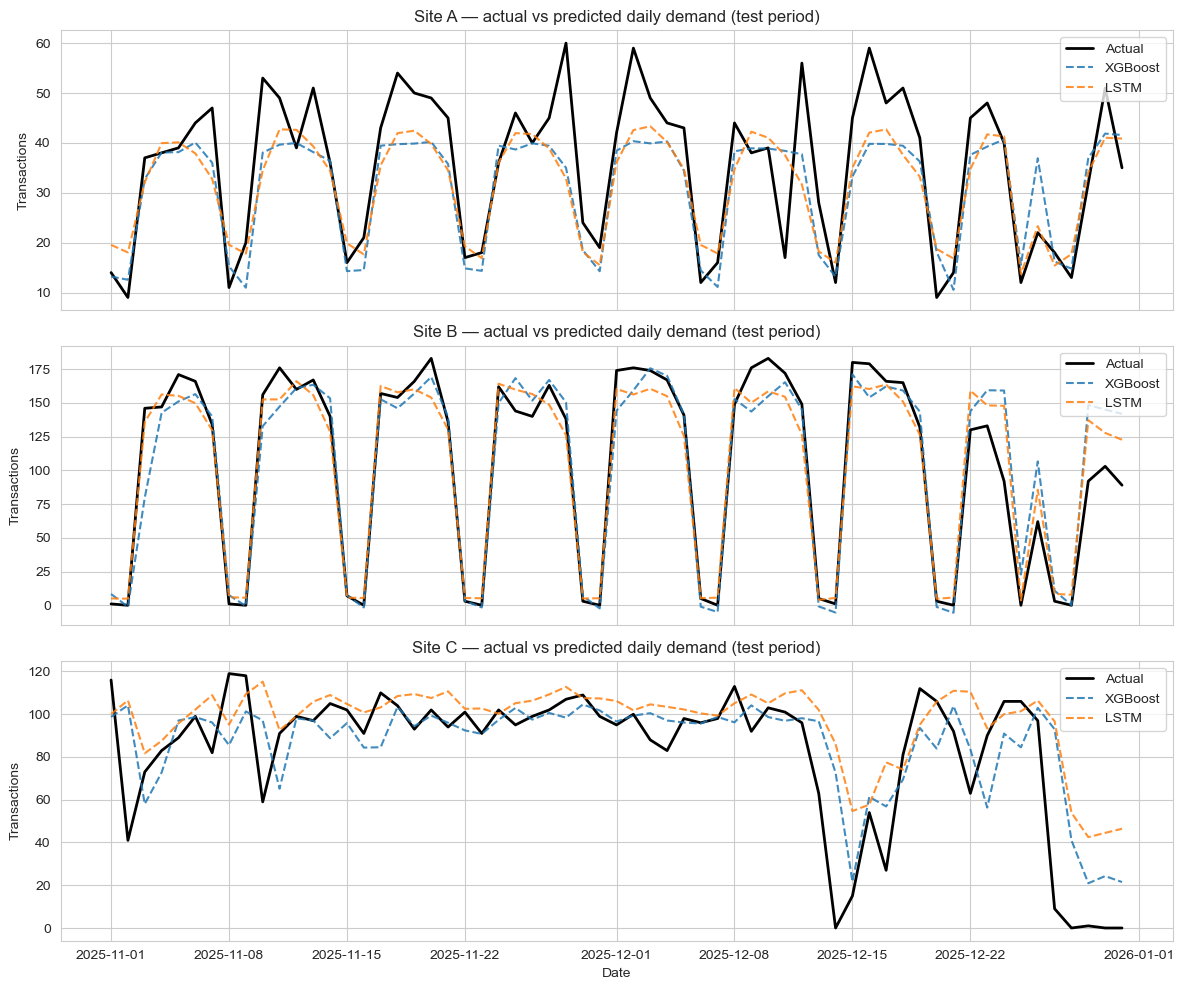

In [178]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, site in zip(axes, sorted(test_df["site_name"].unique())):
    sub = test_df[test_df["site_name"] == site].sort_values("date")
    ax.plot(sub["date"], sub["daily_transactions"], label="Actual",
            color="black", linewidth=2)
    ax.plot(sub["date"], sub["pred_xgb"], label="XGBoost",
            linestyle="--", alpha=0.85)
    ax.plot(sub["date"], sub["pred_lstm"], label="LSTM",
            linestyle="--", alpha=0.85)
    ax.set_title(f"{site} — actual vs predicted daily demand (test period)")
    ax.set_ylabel("Transactions")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "forecast_actual_vs_predicted.png", dpi=150,
            bbox_inches="tight")
plt.show()

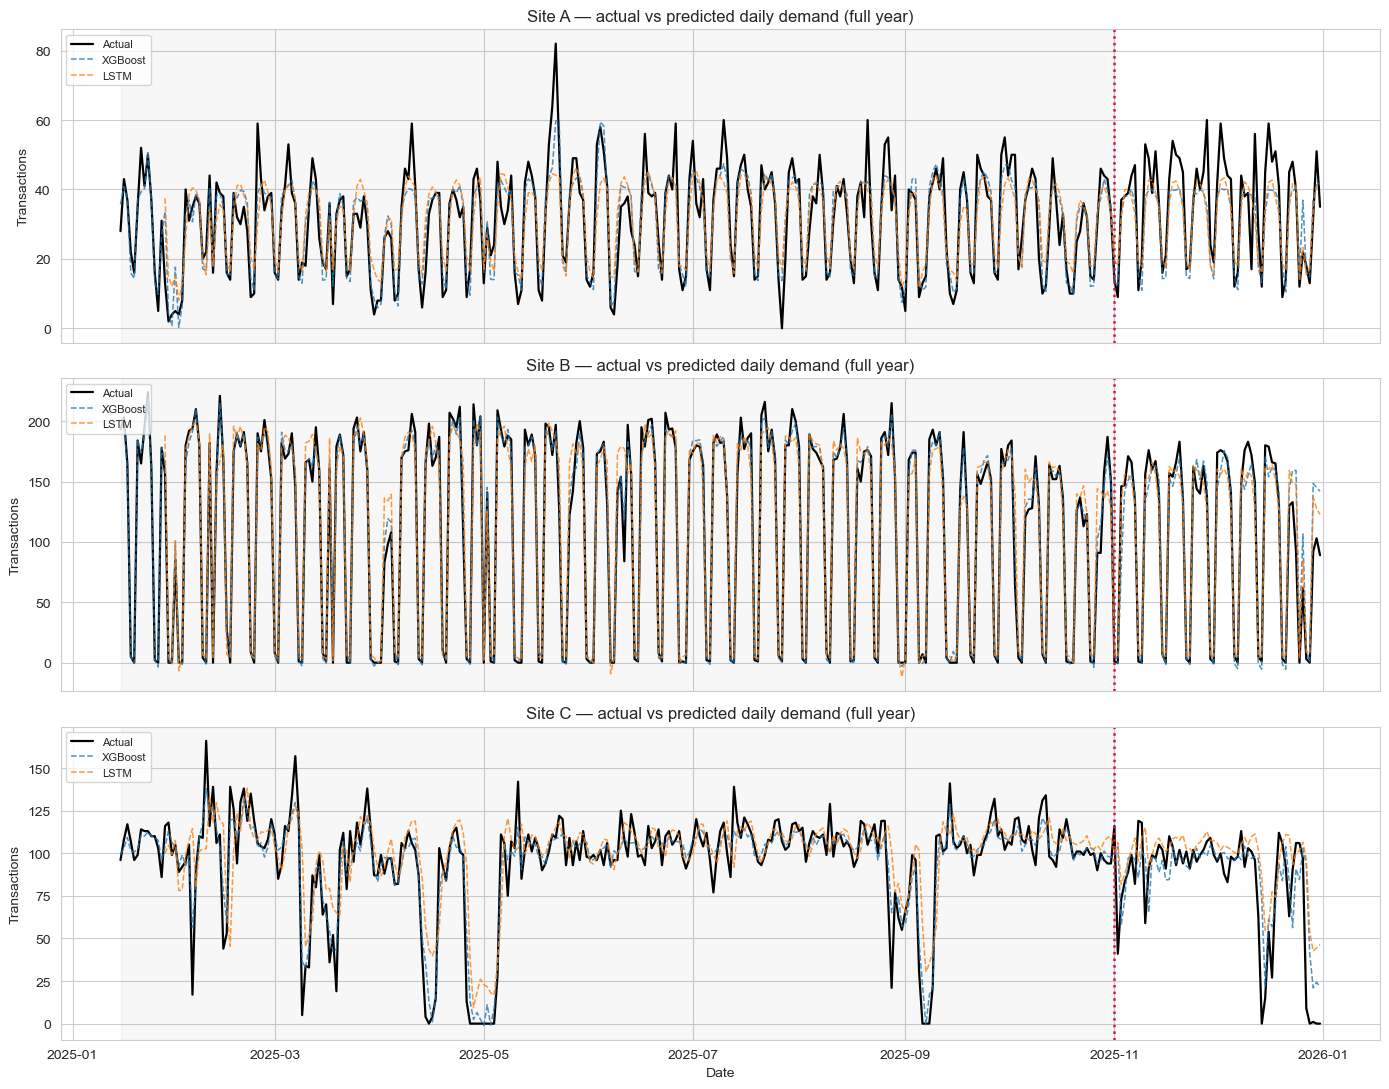

In [177]:
# Predictions across the whole modelling period
full_df = model_df.copy().reset_index(drop=True)
full_df["pred_lr"]  = lr_pipeline.predict(X)
full_df["pred_xgb"] = xgb_model.predict(X)
full_df["site_name"] = full_df[site_cols].idxmax(axis=1).map(site_lookup)

lstm_all = targ_scaler.inverse_transform(
    lstm_model.predict(X_seq, verbose=0)
).flatten()

site_labels = []
for site_col in site_cols:
    n = scaled[scaled[site_col] == 1].shape[0] - (SEQ_LEN - 1)
    site_labels += [site_col.replace("site_", "")] * n

lstm_lookup = pd.DataFrame({
    "date": seq_dates, "site_name": site_labels, "pred_lstm": lstm_all,
})
full_df = full_df.merge(lstm_lookup, on=["date", "site_name"], how="left")

# Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
split_dt = pd.Timestamp(SPLIT_DATE)

for ax, site in zip(axes, sorted(full_df["site_name"].unique())):
    sub = full_df[full_df["site_name"] == site].sort_values("date")
    ax.plot(sub["date"], sub["daily_transactions"], label="Actual",
            color="black", linewidth=1.6)
    ax.plot(sub["date"], sub["pred_xgb"], label="XGBoost",
            linestyle="--", alpha=0.8, linewidth=1.1)
    ax.plot(sub["date"], sub["pred_lstm"], label="LSTM",
            linestyle="--", alpha=0.8, linewidth=1.1)
    ax.axvline(split_dt, color="crimson", linestyle=":", linewidth=1.8)
    ax.axvspan(sub["date"].min(), split_dt, color="grey", alpha=0.06)
    ax.set_title(f"{site} — actual vs predicted daily demand (full year)")
    ax.set_ylabel("Transactions")
    ax.legend(loc="upper left", fontsize=8)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "forecast_full_year.png", dpi=150, bbox_inches="tight")
plt.show()

## Save Models and Dashboard Artefacts

In [2]:
# --- Freeze the reported model so the results never shift again ---
lstm_model.save(MODEL_DIR / "lstm_demand_model.keras")
np.save(MODEL_DIR / "lstm_test_pred.npy", lstm_pred)
summary.to_csv(DASHBOARD_DIR / "lstm_seed_runs.csv", index=False)
print("Saved median LSTM model, its predictions, and the seed summary.")

NameError: name 'lstm_model' is not defined

In [172]:
import joblib

# 1. Trained model + the feature order it expects
joblib.dump(xgb_model, MODEL_DIR / "xgb_demand_model.pkl")
joblib.dump(feature_cols, MODEL_DIR / "feature_cols.pkl")

# 2. Continuous daily series with features
full_df.to_csv(DASHBOARD_DIR / "daily_demand_features.csv", index=False)

# 3. Test-period predictions
test_df.to_csv(DASHBOARD_DIR / "test_predictions.csv", index=False)

# 4. Model performance metrics
pd.DataFrame([
    {"model": "Linear Regression", "MAE": lr_mae,   "RMSE": lr_rmse},
    {"model": "XGBoost",           "MAE": xgb_mae,  "RMSE": xgb_rmse},
    {"model": "LSTM",              "MAE": lstm_mae, "RMSE": lstm_rmse},
]).to_csv(DASHBOARD_DIR / "model_metrics.csv", index=False)

# 5. Temporal patterns (Objective 1)
df.groupby(["site", "entry_hour"]).size().reset_index(name="transactions") \
  .to_csv(DASHBOARD_DIR / "pattern_hourly.csv", index=False)
df.groupby(["site", "entry_day_name"]).size().reset_index(name="transactions") \
  .to_csv(DASHBOARD_DIR / "pattern_weekday.csv", index=False)
df.groupby(["site", "entry_month"]).size().reset_index(name="transactions") \
  .to_csv(DASHBOARD_DIR / "pattern_monthly.csv", index=False)

print("Artifacts saved to:", DASHBOARD_DIR)

Artifacts saved to: C:\Users\irfan\OneDrive\Documents\Education\Degree\Third Year\Sem 2\Investigation (fyp)\fyp part 1\parking_fyp\outputs\dashboard
